<table style="width:100%; border-bottom: 2px solid #333; padding-bottom: 10px; margin-bottom: 20px;">
  <tr>
    <td style="text-align: left; font-size: 1.3em; font-weight: bold;">EPISEN</td>
    <td style="text-align: right; font-size: 0.9em;"><strong>TP2 - Outils mathématiques</strong><br/><span style="font-size: 0.85em;">1FI-FA SPI  &bull; 2026-2027</span></td>
  </tr>
</table>

<div style="text-align: center; margin: 30px 0;">
  <h1>TP2 - Calcul intégral, intégrales impropres, intégrales multiples</h1>
</div>

<div style="border: 1px solid #333; padding: 8px 16px; margin: 20px 0; display: inline-block;">
  <strong>Nom : Valjean</strong> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
  <strong>Prénom : Jean</strong>
</div>

Ce TP aborde les chapitres 2 (Calcul intégral), 5 (Intégrales impropres) et 7 (Intégrales multiples). Python sert ici à trois choses :

1. **vérifier** des calculs faits à la main (IPP, changements de variable, intégrales doubles…) avec le calcul formel (`sympy`) ;
2. **visualiser** (sommes de Riemann, fonctions $x \mapsto \int_a^x f$, domaines d'intégration) ;
3. **expérimenter et se méfier** : un logiciel de calcul formel peut répondre faux si on ne vérifie pas les hypothèses des théorèmes.

On ne cherche pas ici à construire des méthodes numériques d'approximation d'intégrales (trapèzes, étude de l'erreur…) : c'est l'objet du cours d'analyse numérique du S2.

| Exercice | Contenu |
|---|---|
| 1 | Prise en main de `sympy` |
| 2 | Calcul intégral : IPP, changement de variable, sommes de Riemann |
| 3 | Intégrales impropres : définition, critères, sinus cardinal, séries |
| 4 | Intégrales doubles et triples, changements de coordonnées |

 Les questions 📝 se font sur papier, les questions 💻 en Python.

In [2]:
import numpy as np
from math import *
import matplotlib.pyplot as plt
import sympy as sp

sp.init_printing()
x, y, z, t, u, v = sp.symbols('x y z t u v', real=True)

<div style="background-color:#f5f5f5; border-left: 4px solid #333; padding: 8px 16px; margin: 20px 0;">
  <h3 style="margin:0; color:#333;">Exercice 1 - Prise en main de sympy</h3>
</div>

`sympy` manipule des expressions **exactes** : $\sqrt{2}$ reste $\sqrt{2}$, $\pi$ reste $\pi$. Les commandes utiles :

| Commande | Rôle |
|---|---|
| `x = sp.symbols('x', real=True)` | déclarer une variable symbolique |
| `sp.integrate(f, x)` | une primitive de `f` |
| `sp.integrate(f, (x, a, b))` | $\int_a^b f(x)\,dx$ |
| `sp.Integral(f, (x, a, b))` | l'intégrale non évaluée (on l'évalue avec `.doit()`) |
| `sp.diff(f, x)` | dérivée |
| `sp.limit(f, x, a)`, `sp.oo` | limite, $+\infty$ |
| `sp.simplify(e)`, `e.subs(x, 2)`, `e.evalf()` | simplifier, substituer, valeur approchée |
| `sp.lambdify(x, f, 'numpy')` | transformer une expression en fonction Python utilisable par `numpy` |

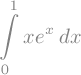

In [3]:
# Exemple
f = x * sp.exp(x)
display(sp.integrate(f, x))           # une primitive
display(sp.integrate(f, (x, 0, 1)))   # intégrale sur [0, 1]
display(sp.Integral(f, (x, 0, 1)))    # intégrale non évaluée

> 💻 **Question 1 —** Calculer avec `sympy` : $\displaystyle\int_0^\pi \sin(x)\mathrm{d}x$ ; une primitive de $x\mapsto \tfrac{1}{1+x^2}$ ; $\displaystyle\lim_{x\to 0}\tfrac{\sin x}{x}$ et $\displaystyle\lim_{x\to+\infty} x^3e^{-x}$.


> 💻 **Question 2 —** Tracer sur $[0;2\pi]$ la fonction $g : t\mapsto t\sin t$ à l'aide de `sp.lambdify` et `matplotlib`.


In [4]:
g = t*sp.sin(t)
g_num = sp.lambdify(t, g, 'numpy')


> 💻 **Question 3 —**  Calculer $\displaystyle\int_0^{2\pi} t\sin t\,dt$, puis $\displaystyle\int_0^{2\pi} |t\sin t|\,dt$ **sans utiliser `Abs`** : utiliser le graphe précédent et la relation de Chasles pour découper l'intervalle. Vérifier l'inégalité triangulaire.


<div style="background-color:#f5f5f5; border-left: 4px solid #333; padding: 8px 16px; margin: 20px 0;">
  <h3 style="margin:0; color:#333;">Exercice 2 - Calcul intégral</h3>
</div>


#### Intégration par parties

On rappelle que si $u$ et $v$ sont de classe $\mathcal{C}^1$ sur $[a;b]$,
$$\int_a^b u(t)\,v'(t)\,dt = \big[u(t)v(t)\big]_a^b - \int_a^b u'(t)\,v(t)\,dt.$$

> 💻 **Question 4 —** Compléter la fonction `ipp` ci-dessous. Elle doit renvoyer le crochet et l'intégrale restante **non évaluée** (avec `sp.Integral`), pour qu'on voie la structure du calcul. Tester sur l'exemple : $\int_0^1 xe^x\,dx$ (avec $u(x)=x$, $v(x)=e^x$), puis comparer avec `sp.integrate`.


In [6]:
def ipp(u_, v_, var, a, b):
    '''IPP pour calculer ∫_a^b u v' : renvoie (crochet [u v]_a^b, intégrale restante ∫_a^b u' v non évaluée).'''
    crochet = ???
    reste = ???
    return crochet, reste

SyntaxError: invalid syntax (1334233356.py, line 3)

In [7]:
c, r = ipp(???)
display(c, r)

SyntaxError: invalid syntax (887169958.py, line 1)

> 💻 **Question 5 —** En appliquant `ipp` sur un segment $[1;x]$ (avec `x` symbolique positif), retrouver la primitive de $\ln$ qui s'annule en $1$, puis une primitive de $\arctan$ sur $\mathbb{R}$ (on écrira $\arctan = \arctan\times 1$). Vérifier chaque résultat en le dérivant.


In [9]:
x = sp.symbols('x', positive=True)
c, r = ipp(sp.log(t), t, t, 1, x)
P_ln = sp.simplify(c - r.doit())
display(P_ln, sp.simplify(sp.diff(P_ln, x)))

c, r = ???
P_atan = ???
display(???)

SyntaxError: invalid syntax (1000042400.py, line 6)

Pour $n\in\mathbb{N}$, on pose $I_n=\displaystyle\int_0^1 x^ne^x\,dx$.

> 📝 **Question 6 —** Calculer $I_0$ et montrer par IPP que $I_n = e - n\,I_{n-1}$ pour $n\geq 1$. Montrer ensuite, avec la croissance de l'intégrale, que $$\tfrac{1}{n+1}\le I_n\le \tfrac{e}{n+1}.$$ En déduire $\lim I_n$.


> 💻 **Question 7 —** Avec `sympy`, calculer $I_0,\dots,I_{10}$ de deux façons (directement, et avec la récurrence en valeurs exactes) et vérifier qu'elles coïncident.


In [12]:
n_max = 10
I_direct = ???
I_rec = [sp.E - 1]
for n in range(1, n_max + 1):
    I_rec.append(???)


SyntaxError: invalid syntax (4214630035.py, line 2)

#### Changement de variable

On rappelle que si $f$ est continue sur $I$ et $\varphi$ de classe $\mathcal{C}^1$ sur $J$ **à valeurs dans $I$**, alors
$$\int_\alpha^\beta f(\varphi(s))\,\varphi'(s)\,ds=\int_{\varphi(\alpha)}^{\varphi(\beta)} f(x)\,dx.$$

> 💻 **Question 8 —** Compléter la fonction `cdv` qui, pour une intégrale $\int f(\text{var})\,d\text{var}$, construit l'intégrale **non évaluée** obtenue en posant « var $=\varphi$(new) », le paramètre new variant de $\alpha$ à $\beta$. Refaire l'exemple de cours : $$\int_0^{\tfrac{1}{2}}\sqrt{1-t^2}\mathrm{d}t\text{ avec }t=\sin u.$$ On utilisera les méthodes `sp.subs`et `sp.diff`. Il est conseillé d'écrire `sp.Rational(1,2)`plutôt que `1/2`.

In [13]:
def cdv(f, var, phi, new, alpha, beta):
    '''Intégrale obtenue en posant var = phi(new), new allant de alpha à beta (non évaluée).'''
    integrande = sp.simplify(???)
    return sp.Integral(integrande, (new, alpha, beta))

SyntaxError: invalid syntax (3004012739.py, line 3)

> 📝 **Question 9 —** Pourquoi `sympy` fait-il apparaître une valeur absolue ? Comment la retire-t-on à la main ?


> 💻 **Question 10 —** Refaire l'exemple de cours : $$\displaystyle\int_0^1\tfrac{\ln(1+e^t)}{1+e^{-t}}\,dt\text{ avec }x=1+e^t,$$ c'est-à-dire $t=\ln(x-1)$, $x$ allant de $2$ à $1+e$. Vérifier qu'on obtient bien $\displaystyle\int_2^{1+e}\tfrac{\ln x}{x}\,dx$ et la valeur du cours.


**Point de vigilance.** On considère $J=\displaystyle\int_{-1}^1\tfrac{dx}{1+x^2}$.

> 💻 **Question 11 —** Que vaut $J$ ?  Utiliser ensuite `cdv` avec le changement de variable « $x=1/s$ », $s$ allant de $-1$ à $1$ (on a bien $\varphi(-1)=-1$ et $\varphi(1)=1$). Que renvoie le calcul ?


In [14]:
s = sp.symbols('s', real=True)


> 📝 **Question 12 —** Expliquer la contradiction : quelle hypothèse du théorème de changement de variable n'est pas vérifiée ?


#### Sommes de Riemann

On rappelle que si $f$ est continue sur $[a;b]$,
$$S_n(f)=\tfrac{b-a}{n}\sum_{k=1}^n f\!\left(a+k\,\tfrac{b-a}{n}\right)\xrightarrow[n\to+\infty]{}\int_a^b f(t)\,dt.$$

> 💻 **Question 13 —** Écrire une fonction `riemann(f, a, b, n)` (avec `numpy`, **sans boucle `for`**) qui renvoie $S_n(f)$, où `f` est une fonction Python. Calculer $S_n(\exp)$ sur $[0;1]$ pour $n=10, 100, 1000, 10^4$ et comparer à la valeur exacte.
> <div style="background-color:#f5f5f5; border-left: 4px solid #aaa; padding: 8px 16px; margin: 10px 0;">
  <p style="margin:0;">💡 <strong>Indication —</strong> <code>np.arange(1, n + 1)</code> donne le tableau des entiers de $1$ à $n$.</p>
</div>


In [16]:
def riemann(f, a, b, n):
    ???
    return ???

for n in [10, 100, 1000, 10**4]:
    print(n, riemann(np.exp, 0, 1, n), ???)

SyntaxError: invalid syntax (3951793317.py, line 3)

> 💻 **Question 14 —** Écrire une fonction `trace_riemann(f, a, b, n)` qui trace le graphe de $f$ et les $n$ rectangles de la somme $S_n(f)$ (comme sur la figure du cours). L'essayer avec $f(x)=\sin x+1{,}5$ sur $[0;2\pi]$ pour $n=8$ puis $n=30$.
> <div style="background-color:#f5f5f5; border-left: 4px solid #aaa; padding: 8px 16px; margin: 10px 0;">
  <p style="margin:0;">💡 <strong>Indication —</strong> on pourra utiliser <code>plt.bar(..., width=h, align='edge', alpha=0.4)</code>.</p>
</div>


In [20]:
def trace_riemann(f, a, b, n):
    ???
    ???          # bord gauche de chaque rectangle
    ???             # f évaluée au bord droit : a + k h, k = 1..n
    X = np.linspace(a, b, 500)
    plt.plot(X, f(X), 'k')
    plt.bar(???, ???, width=h, align='edge', alpha=0.4, edgecolor='C1', color='C1')
    plt.title(f"n = {n},  S_n = {riemann(f, a, b, n):.5f}")
    plt.show()

f = lambda X: np.sin(X) + 1.5



SyntaxError: invalid syntax (1200316508.py, line 7)

> 💻 **Question 15 —** On pose $u_n=\displaystyle\sum_{k=0}^{n-1}\tfrac{1}{n+k}$. Calculer numériquement $u_n$ pour quelques valeurs de $n$ et comparer à $\ln 2$. 


On considère les suites
$$a_n=\sum_{k=1}^n\tfrac{n}{n^2+k^2},\qquad b_n=\tfrac1n\sum_{k=1}^n\sin\!\left(\tfrac{k\pi}{n}\right),\qquad c_n=\sum_{k=1}^n\tfrac{k}{n^2+k^2},\qquad d_n=\left(\prod_{k=1}^n\left(1+\tfrac kn\right)\right)^{\tfrac{1}{n}}.$$

> 📝 **Question 16 —** Pour chaque suite, reconnaître une somme de Riemann (préciser $f$, $a$, $b$) et en déduire la limite.
> <div style="background-color:#f5f5f5; border-left: 4px solid #aaa; padding: 8px 16px; margin: 10px 0;">
  <p style="margin:0;">💡 <strong>Indication —</strong> On pourra étudier $\ln d_n$.</p>
</div>


> 💻 **Question 17 —** Vérifier ces limites avec `sympy` (calcul de l'intégrale) et avec `numpy` (calcul du terme pour $n=10^5$).


<div style="background-color:#f5f5f5; border-left: 4px solid #333; padding: 8px 16px; margin: 20px 0;">
  <h3 style="margin:0; color:#333;">Exercice 3 - Intégrales impropres</h3>
</div>


#### La définition, vue graphiquement

On rappelle que pour $f$ continue sur $[a;b[$, $\int_a^b f$ converge si $F(\mu)=\int_a^\mu f(t)\,dt$ a une limite finie quand $\mu\to b^-$. Étudier une intégrale impropre, c'est donc étudier une fonction de $\mu$.

> 💻 **Question 18 —** Pour les trois intégrales suivantes : $\displaystyle\int_0^{+\infty}e^{-x}\,dx$, $\displaystyle\int_0^1\tfrac{dx}{x}$, $\displaystyle\int_0^{+\infty}\sin x\,dx$, calculer $F(\mu)$ avec `sympy` (pour la deuxième, on intègre sur $[\mu;1]$ et $\mu\to0^+$), calculer la limite avec `sp.limit`, et tracer $F$. Conclure sur la nature de chaque intégrale. Que signifie la réponse `AccumBounds` renvoyée pour la troisième ?


#### Intégrales de Riemann

> 💻 **Question 19 —** Pour $\alpha\in\{\frac12,1,\frac32,2,3\}$, calculer avec `sympy` $\displaystyle\int_1^{+\infty}\tfrac{dx}{x^\alpha}$ et $\displaystyle\int_0^1\tfrac{dx}{x^\alpha}$ (utiliser `sp.Rational(1, 2)` et non `0.5`). On utilisera `sp.oo`.


> 💻📝 **Question 20 —** **Ne pas croire aveuglément le logiciel.** Calculer avec `sympy` $\displaystyle\int_1^2\tfrac{dx}{x-2}$ et $\displaystyle\int_0^3\tfrac{x^2-2x+5}{x^2-1}\,dx$. Les réponses ont-elles un sens pour une intégrale de fonction réelle ? Pourquoi ?


#### Le sinus cardinal : convergence

On étudie $\displaystyle\int_0^{+\infty}\tfrac{\sin x}{x}\,dx$ 

> 📝 **Question 21 —** Justifier la convergence de $\displaystyle\int_0^1\tfrac{\sin x}{x}\,dx$.


> 💻 **Question 22 —** Sur $[1;\mu]$, faire une IPP avec la fonction `ipp` (prendre $u=1/x$ et $v=-\cos x$). Montrer à la main que l'intégrale restante est absolument convergente quand $\mu\to+\infty$, et conclure.


In [21]:
c, r = ipp(???)
display(c, r)

SyntaxError: invalid syntax (887169958.py, line 1)

> 💻 **Question 23 —** `sympy` sait calculer $F(\mu)=\int_0^\mu\frac{\sin x}{x}\,dx$ : il l'appelle `Si(mu)` (sinus intégral). Tracer $F$ sur $[0;50]$ et conjecturer la valeur de l'intégrale. Vérifier avec `sp.limit`.
>
> On pourra tracer la droite horizontale d'équation $y=\tfrac{\pi}{2}$.


#### Comparaison séries–intégrales

On rappelle que si $f$ est continue et **décroissante** sur $[n_0;+\infty[$, $\int_{n_0}^{+\infty}f$ et $\sum f(n)$ sont de même nature. La démonstration repose sur l'encadrement, pour $k\ge n_0+1$ :
$$\int_k^{k+1}f(t)\,dt\le f(k)\le\int_{k-1}^k f(t)\,dt.$$

> 💻 **Question 24 —** Écrire une fonction `trace_encadrement(f, n0, n1)` qui trace $f$ sur $[n_0;n_1]$ ainsi que les rectangles de hauteur $f(k)$ posés sur $[k;k+1]$ et sur $[k-1;k]$ (deux graphiques). Relier la figure à l'encadrement ci-dessus. L'essayer avec $f(t)=1/t$ sur $[1;8]$.


On note $H_N=\displaystyle\sum_{k=1}^N\frac1k$.

> 📝 **Question 25 —** À l'aide de l'encadrement, montrer que $\ln(N+1)\le H_N\le 1+\ln N$.


> 💻 **Question 26 —** Tracer $N\mapsto H_N-\ln N$ pour $N\le10^6$ (utiliser `np.cumsum`). Conjecturer.


In [22]:
N = 10**6
k = np.arange(1, N + 1)
H = np.cumsum(???)


SyntaxError: invalid syntax (2528338981.py, line 3)

<div style="background-color:#f5f5f5; border-left: 4px solid #333; padding: 8px 16px; margin: 20px 0;">
  <h3 style="margin:0; color:#333;">Exercice 4 - Intégrales multiples</h3>
</div>


#### Intégrales doubles et théorème de Fubini

Avec une description hiérarchisée $x\in[a;b]$, $y\in[u(x);v(x)]$, on calcule d'abord l'intégrale intérieure en $y$ (à $x$ fixé), puis en $x$ : `sp.integrate(f, (y, u(x), v(x)), (x, a, b))` — les bornes s'écrivent **de l'intérieur vers l'extérieur**.

> 💻 **Question 27 —** Écrire une fonction `trace_domaine(u_, v_, a, b)` qui représente le domaine $\{x\in[a;b],\ u(x)\le y\le v(x)\}$. Représenter le domaine $$D=\left\{ (x,y)\in\mathbb{R}^2 \, \lvert \, x\geq 0, y\geq 0\mbox{ et }x+y\leq 1\right\},$$ puis calculer $\iint_D xy\,dx\,dy$ dans **les deux ordres**.
> <div style="background-color:#f5f5f5; border-left: 4px solid #aaa; padding: 8px 16px; margin: 10px 0;">
  <p style="margin:0;">💡 <strong>Indication —</strong> utiliser <code>plt.fill_between</code>.</p>
</div>


In [23]:
def trace_domaine(u_, v_, a, b, titre=""):
   

_IncompleteInputError: incomplete input (2564849083.py, line 2)

> 📝 **Question 28 —** Soit $\Delta=\{(x,y)\in\mathbb{R}^2\mid 0\le x\le1,\ x^2\le y\le\sqrt x\}$. Donner les deux descriptions hiérarchisées de $\Delta$.


> 💻 **Question 29 —** Représenter $\Delta$. Calculer $\iint_\Delta(x+y)\,dx\,dy$ dans les deux ordres, et l'aire de $\Delta$.


**(Fubini sauve la mise)** On veut calculer $\displaystyle\int_0^1\left(\int_x^1 e^{y^2}\,dy\right)dx$.

> 💻 **Question 30 —** Pourquoi est-ce impossible à la main dans cet ordre ? Que renvoie `sympy` (chercher ce qu'est la fonction `erfi`) ?


> 📝 **Question 31 —** Dessiner le domaine, le décrire dans l'autre ordre, et calculer l'intégrale **à la main** avec Fubini.


> 💻 **Question 32 —** Vérifier numériquement que les deux résultats coïncident.
